# Ensemble: Chronos-2 + a spatial GNN

One notebook, end to end. It trains both models, blends them, and prints a
single results table at the bottom.

**Order of operations**

| part | what it does | cost |
|---|---|---|
| 1 | spatial diagnostic - is there neighbour signal at all? | ~10 min |
| 2 | Chronos-2 over the 2023 tuning and 2024 evaluation windows | ~15 min (T4) |
| 3 | trains the GNN, predicts both window sets | the expensive one |
| 4 | fits the blend weight on 2023, applies it to 2024 | ~1 min |
| 5 | the full results table | seconds |

## The rule that makes this honest

The blend weight is **fitted on 2023 windows and never on 2024**. A weight fitted
on the evaluation year is leakage, and it is the easy mistake here: it would make
any ensemble look good. So this notebook enumerates a *tuning* window set from
2023 using the identical eligibility rule as the frozen 2024 set, runs both
models over it, and fits there.

The same rule binds the GNN. Its early stopping picks the best epoch on a slice
held out from the **training years** - not on 2023 (which would bias the blend
weight) and not on 2024 (which would be outright leakage). The earlier GNN
notebook early-stopped on the 2024 evaluation windows; every number it printed
was optimistic for that reason, and they are not comparable with the table at the
bottom of this one.

Everything expensive is checkpointed to Drive and reused on a re-run, so a Colab
disconnect costs minutes rather than hours.

In [1]:
# ---- bootstrap: shared artifacts + the dataset --------------------------
SHARED_FOLDER_ID = "1ivElb2AifDNvIg47Ii6dV_XP9aO14WSE"
CLEAN_FILE_ID    = "1QyfzghimgyRhQ735k42JetDEoK5kfGZJ"

SHARED = "shared"
CLEAN  = "bih_hourly_clean.csv"

import os, sys, json, subprocess
import numpy as np
import pandas as pd

POLLUTANTS = ["pm10", "pm25", "so2", "no2", "o3", "co"]
MET        = ["temperature", "wind_speed", "wind_u", "wind_v"]


def _gdown():
    try:
        import gdown
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "gdown"], check=True)
        import gdown
    return gdown


if not os.path.exists(os.path.join(SHARED, "bih_shared.py")):
    print("fetching the shared artifacts")
    _gdown().download_folder(id=SHARED_FOLDER_ID, output=SHARED, quiet=True)

if not os.path.exists(CLEAN) or os.path.getsize(CLEAN) < 1e8:
    print("fetching bih_hourly_clean.csv (~167 MB)")
    _gdown().download(id=CLEAN_FILE_ID, output=CLEAN, quiet=False)

_hdr = pd.read_csv(CLEAN, nrows=0).columns.tolist()
_need = ["datetime", "station"] + POLLUTANTS + [f"{p}_filled" for p in POLLUTANTS] + MET
_missing = [c for c in _need if c not in _hdr]
if _missing:
    raise SystemExit(
        f"\n{CLEAN} is not the hourly clean export - missing {_missing}.\n"
        f"Delete the downloaded file before retrying, or the stale copy is reused."
    )

sys.path.append(SHARED)
import bih_shared as bs

SPLIT   = bs.load_split(SHARED)
GROUPS  = bs.load_groups(SHARED)

# Results live on Drive when it can be mounted, so a Colab disconnect does not
# take the cached predictions with it. Set DRIVE = False to keep them local.
DRIVE = True
RESULTS = "results_ensemble"
if DRIVE:
    try:
        from google.colab import drive
        drive.mount("/content/drive")
        RESULTS = "/content/drive/MyDrive/results_ensemble"
    except Exception as e:
        print("no Drive ({}), results stay on the local disk".format(e))
os.makedirs(RESULTS, exist_ok=True)
print("results ->", RESULTS)

try:
    import chronos
    from chronos import Chronos2Pipeline   # noqa: F401
except Exception:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "chronos-forecasting>=2.3.0"], check=True)
    import chronos

try:
    import torch_geometric  # noqa: F401
except Exception:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "torch_geometric"], check=True)

import torch
from chronos import BaseChronosPipeline

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("torch", torch.__version__, "| device:", DEVICE)
if DEVICE == "cpu":
    print("\nNo GPU - Parts 2 and 3 will take hours. Runtime > Change runtime type > T4 GPU.")

fetching the shared artifacts
fetching bih_hourly_clean.csv (~167 MB)


Downloading...
From (original): https://drive.google.com/uc?id=1QyfzghimgyRhQ735k42JetDEoK5kfGZJ
From (redirected): https://drive.google.com/uc?id=1QyfzghimgyRhQ735k42JetDEoK5kfGZJ&confirm=t&uuid=6b0521fa-e511-45ae-b228-f8e850a0f875
To: /content/bih_hourly_clean.csv
100%|██████████| 167M/167M [00:09<00:00, 18.4MB/s]


no Drive (mount failed), results stay on the local disk
results -> results_ensemble
torch 2.11.0+cu128 | device: cuda


In [2]:
# ---- configuration ------------------------------------------------------
MODEL     = "amazon/chronos-2"
CONTEXT   = 512
HORIZON   = SPLIT["horizon_hours"]
QUANTILES = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
MEDIAN    = QUANTILES.index(0.5)
BATCH     = 64 if DEVICE == "cuda" else 16

KNOWN_FUTURE = ["temperature", "wind_speed"]   # observed - see the caveat below
PAST_ONLY    = ["wind_u", "wind_v"]

# Heating season, matching the earlier Sarajevo work.
HEATING_MONTHS = (10, 11, 12, 1, 2, 3)

# --- Part 1 -------------------------------------------------------------
DIAG_N        = 400      # Sarajevo windows for the spatial diagnostic
DIAG_POLS     = ["pm10", "no2", "pm25"]
N_NEIGHBOURS  = 3

# --- Part 2 -------------------------------------------------------------
EVAL_N  = None    # None = all 31,688 frozen 2024 windows
TUNE_N  = 6000    # 2023 windows to fit blend weights on; 12 scalars need no more

# Run Chronos a SECOND time with the neighbouring stations as past covariates.
# Part 1 measures this configuration at +2.1% over weather-only, which is a
# larger gain than the blend has ever produced - so it is run over the full
# window sets and scored as a model in its own right.
RUN_CHRONOS_NBR = True

# --- Part 3 (the GNN) ---------------------------------------------------
# Each pollutant is a separate partition with its own station set and its own
# trained model, so this list is the main runtime knob. Pollutants left out
# simply get no partner, and their blend cell falls back to Chronos alone.
GNN_POLLUTANTS = ["pm25", "pm10"]
GNN_CONTEXT    = 168     # 1 week of hourly history into the ConvLSTM
GNN_EPOCHS     = 30
GNN_PATIENCE   = 5
GNN_BATCH      = 32
GNN_HIDDEN     = 64
GNN_HEADS      = 4
GNN_DROPOUT    = 0.3
GNN_LR         = 1e-3
GNN_WD         = 1e-3
GNN_K          = 3       # neighbours per station in the close_to graph
GNN_MAX_KM     = 20
GNN_VAL_DAYS   = 60      # held out from the END of the training years for early
                         # stopping. Never 2023 (biases the blend weight) and
                         # never 2024 (leakage).

# An external partner instead of / alongside the GNN. None = use the GNN.
PARTNER_CSV = None

# NOTE, carried from the Chronos notebook: the weather covariates are OBSERVED
# over the horizon, which is not knowable at forecast time. A deployment would
# feed a numerical weather forecast. Every number below inherits that caveat.
print("heating months:", HEATING_MONTHS, "| context:", CONTEXT, "| horizon:", HORIZON)
print("GNN pollutants:", GNN_POLLUTANTS)

heating months: (10, 11, 12, 1, 2, 3) | context: 512 | horizon: 24
GNN pollutants: ['pm25', 'pm10']


## Load the panel, the weather, and the station geometry

In [3]:
panel = bs.load_panel(CLEAN, SHARED)
HOURS = next(iter(panel.values())).index
POS   = {t: i for i, t in enumerate(HOURS)}


def load_met(clean_csv, index):
    """{station: (n_hours, n_met)} on the panel's gap-free hourly index."""
    df = pd.read_csv(clean_csv, usecols=["station", "datetime"] + MET,
                     parse_dates=["datetime"])
    return {st: (g.drop_duplicates("datetime").set_index("datetime")
                  .reindex(index)[MET].to_numpy("float32"))
            for st, g in df.groupby("station", sort=True)}


met    = load_met(CLEAN, HOURS)
coords = pd.read_csv(os.path.join(SHARED, "station_coords.csv"))
dist   = pd.read_csv(os.path.join(SHARED, "station_distance_km.csv"), index_col=0)
wins   = bs.load_windows(SHARED)


def season_of(ts):
    m = ts.month
    return ("winter" if m in (12, 1, 2) else "spring" if m in (3, 4, 5)
            else "summer" if m in (6, 7, 8) else "autumn")


def annotate(w):
    w = w.copy()
    w["season"] = w.origin.map(season_of)
    w["regime"] = np.where(w.origin.dt.month.isin(HEATING_MONTHS),
                           "heating", "non_heating")
    return w


wins = annotate(wins)
print(f"{len(panel)} series | {len(wins):,} frozen 2024 windows")
print(wins.groupby("regime").size().to_string())

/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcas

107 series | 31,688 frozen 2024 windows
regime
heating        15622
non_heating    16066


## Part 1 - does neighbour information exist?

Sarajevo is the strongest possible test: six stations inside ~10 km of the same
basin, sharing the same inversion, plus Ivan Sedlo 30 km out at 969 m as a
regional-background contrast. If cross-station signal cannot be found here, it is
not in this network.

Three configurations, on identical windows:

| config | what the model sees |
|---|---|
| `weather` | own history + temperature/wind (the current best Chronos setup) |
| `weather+nbr` | the above, plus the 3 nearest co-measuring stations' history |
| `nbr_only` | own history + neighbours, no weather - isolates the spatial term |

Neighbours are given as **past** covariates only. Their future is no more
knowable than the target's.

This part is cheap and it is the justification for Part 3. If it comes back flat,
the GNN is not worth its training cost.

In [4]:
def nearest(station, pollutant, k=N_NEIGHBOURS):
    """The k nearest stations that also measure this pollutant. Not restricted
    to the same city - if the nearest co-measuring station is elsewhere, that is
    still the nearest one."""
    have = [s for s in dist.index if (s, pollutant) in panel and s != station]
    if not have or station not in dist.index:
        return []
    return list(dist.loc[station, have].sort_values().index[:k])


def make_inputs(chunk, weather=True, neighbours=False):
    """One dict per window; all share a schema, as Chronos-2 requires."""
    items = []
    for w in chunk.itertuples():
        i, lo = POS[w.origin], max(0, POS[w.origin] - CONTEXT)
        item = {"target": panel[(w.station, w.pollutant)].y.to_numpy("float32")[lo:i]}
        past, fut = {}, {}
        if weather:
            m = met.get(w.station)
            if m is None:
                m = np.full((len(HOURS), len(MET)), np.nan, "float32")
            for name in KNOWN_FUTURE + PAST_ONLY:
                j = MET.index(name)
                past[name] = m[lo:i, j]
                if name in KNOWN_FUTURE:
                    fut[name] = m[i:i + HORIZON, j]
        if neighbours:
            nb = nearest(w.station, w.pollutant)
            for k in range(N_NEIGHBOURS):
                # Absent neighbour -> an all-NaN series, which keeps the schema
                # identical across windows. Chronos-2 masks NaNs itself.
                if k < len(nb):
                    past[f"nbr{k+1}"] = panel[(nb[k], w.pollutant)].y.to_numpy("float32")[lo:i]
                else:
                    past[f"nbr{k+1}"] = np.full(i - lo, np.nan, "float32")
        if past:
            item["past_covariates"] = past
            if fut:
                item["future_covariates"] = fut
        items.append(item)
    return items


def forecast(w, pipeline, weather=True, neighbours=False, batch=BATCH, verbose=True,
             ckpt=None, ckpt_every=25):
    """Returns (n, 24, 9). Chronos-2's batch_size counts SERIES (target plus
    every covariate), so it is scaled by the schema width - getting that wrong
    is a silent 5x slowdown, not an error."""
    from time import time
    width = 1 + (len(KNOWN_FUTURE) + len(PAST_ONLY) if weather else 0) \
              + (N_NEIGHBOURS if neighbours else 0)

    # Checkpointing. `ckpt` names a partial file under RESULTS holding the rows
    # finished so far; a re-run picks up from row len(partial) instead of zero.
    # Rows are always appended in window order, so the prefix is unambiguous.
    part = os.path.join(RESULTS, f"chronos_{ckpt}.partial.npy") if ckpt else None
    out, start = [], 0
    if part and os.path.exists(part):
        prev = np.load(part)
        if len(prev) > len(w):
            print(f"  {os.path.basename(part)} has {len(prev):,} rows for a "
                  f"{len(w):,}-row set - ignoring it, delete it to be sure")
        else:
            out, start = [prev], len(prev)
            print(f"  resuming from {start:,}/{len(w):,} saved rows", flush=True)

    def _flush():
        if part and out:
            # write-then-rename, so a disconnect mid-save cannot leave a
            # truncated file. The temp name must end in .npy or np.save
            # appends it and os.replace looks for a file that never existed.
            tmp = part + ".tmp.npy"
            np.save(tmp, np.concatenate(out))
            os.replace(tmp, part)

    t0 = time()
    for i in range(start, len(w), batch):
        items = make_inputs(w.iloc[i:i + batch], weather, neighbours)
        q, _ = pipeline.predict_quantiles(items, prediction_length=HORIZON,
                                          quantile_levels=QUANTILES,
                                          batch_size=batch * width)
        out.append(np.stack([t.numpy().reshape(HORIZON, len(QUANTILES)) for t in q]))
        done = i + len(items)
        nb_done = (done - start + batch - 1) // batch
        if part and (nb_done % ckpt_every == 0 or done >= len(w)):
            _flush()
        if verbose and (nb_done % 25 == 0 or done >= len(w)):
            el, todo = time() - t0, len(w) - done
            rate = (done - start) / max(el, 1e-9)
            print(f"  {done:>6,}/{len(w):,}  {el:5.0f}s, ~{todo / max(rate, 1e-9):5.0f}s left",
                  flush=True)
    return np.clip(np.concatenate(out), 0, None)


def evaluate(preds_q, w, name):
    """Per-window MAE/RMSE/MASE/WQL. The MASE denominator always comes from the
    last 512 h, so these line up with baseline_windows.csv."""
    point, rows, wq = preds_q[:, :, MEDIAN], [], []
    for i, r in enumerate(w.itertuples()):
        y, mask = bs.target(panel, r.station, r.pollutant, r.origin)
        ctx = bs.context(panel, r.station, r.pollutant, r.origin, 512)
        rows.append({"model": name, **bs.score(point[i], y, mask, bs.mase_scale(ctx))})
        yt = np.where(mask, y, np.nan)[:, None]
        lv = np.array(QUANTILES)[None, :]
        d = yt - preds_q[i]
        pin = np.maximum(lv * d, (lv - 1) * d)
        den = np.nansum(np.abs(yt)) * len(QUANTILES)
        wq.append(np.nansum(pin) / den if den > 0 else np.nan)
    out = pd.concat([w.reset_index(drop=True), pd.DataFrame(rows)], axis=1)
    out["wql"] = wq
    return out


pipeline = BaseChronosPipeline.from_pretrained(MODEL, device_map=DEVICE,
                                               torch_dtype=torch.float32)
print("loaded", MODEL)

config.json:   0%|          | 0.00/1.07k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  478MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

loaded amazon/chronos-2


In [5]:
SARAJEVO = sorted(coords[coords.city == "Sarajevo"].station)
diag = wins[wins.station.isin(SARAJEVO) & wins.pollutant.isin(DIAG_POLS)]
diag = (diag.sample(min(DIAG_N, len(diag)), random_state=0)
            .sort_values(["station", "pollutant", "origin"]).reset_index(drop=True))
print(f"{len(diag)} Sarajevo windows, "
      f"{diag.groupby(['station','pollutant']).ngroups} series\n")

nb_km = [dist.loc[r.station, n] for r in diag.itertuples()
         for n in nearest(r.station, r.pollutant)]
print(f"median neighbour distance: {np.median(nb_km):.1f} km\n")

DIAG_CSV = os.path.join(RESULTS, "spatial_diagnostic.csv")
if os.path.exists(DIAG_CSV):
    dg = pd.read_csv(DIAG_CSV, parse_dates=["origin"])
    print("reusing the cached diagnostic\n")
else:
    diag_rows = []
    for name, kw in [("weather",     dict(weather=True,  neighbours=False)),
                     ("weather+nbr", dict(weather=True,  neighbours=True)),
                     ("nbr_only",    dict(weather=False, neighbours=True))]:
        diag_rows.append(evaluate(forecast(diag, pipeline, verbose=False, **kw), diag, name))
        print(f"{name} done", flush=True)
    dg = pd.concat(diag_rows, ignore_index=True)
    dg.to_csv(DIAG_CSV, index=False)

print("SPATIAL DIAGNOSTIC - MASE\n")
tab = dg.pivot_table(index="model", values="mase", aggfunc="mean").sort_values("mase")
tab["vs_weather_%"] = (1 - tab.mase / tab.loc["weather", "mase"]) * 100
print(tab.to_string(float_format=lambda v: f"{v:8.4f}"))
print("\nby regime\n")
print(dg.pivot_table(index="regime", columns="model", values="mase")
        .to_string(float_format=lambda v: f"{v:8.4f}"))
print("\nby pollutant\n")
print(dg.pivot_table(index="pollutant", columns="model", values="mase")
        .to_string(float_format=lambda v: f"{v:8.4f}"))

SPATIAL_GAIN = (1 - tab.loc["weather+nbr", "mase"] / tab.loc["weather", "mase"]) * 100
print(f"""

READ THIS AS:
  neighbours change MASE by {SPATIAL_GAIN:+.1f}% over the weather-only configuration.
  > +2%   spatial signal is real - a graph model has something to find.
  0 to +2%  marginal; the GNN would have to be very good to beat the blend cost.
  <= 0%   Chronos cannot use neighbours. That does NOT prove a GNN cannot -
          a graph model represents space explicitly, whereas Chronos sees the
          neighbours as unstructured extra series - but it removes the cheap
          evidence for it, and the GNN should then be justified on its own
          results rather than on the premise.""")

400 Sarajevo windows, 20 series

median neighbour distance: 7.5 km

weather done
weather+nbr done
nbr_only done
SPATIAL DIAGNOSTIC - MASE

                mase  vs_weather_%
model                             
weather+nbr   0.7768        2.1098
weather       0.7935        0.0000
nbr_only      0.8060       -1.5724

by regime

model        nbr_only  weather  weather+nbr
regime                                     
heating        0.9010   0.8691       0.8528
non_heating    0.7110   0.7179       0.7007

by pollutant

model      nbr_only  weather  weather+nbr
pollutant                                
no2          0.8133   0.7746       0.7669
pm10         0.7577   0.7746       0.7475
pm25         0.8686   0.8541       0.8385


READ THIS AS:
  neighbours change MASE by +2.1% over the weather-only configuration.
  > +2%   spatial signal is real - a graph model has something to find.
  0 to +2%  marginal; the GNN would have to be very good to beat the blend cost.
  <= 0%   Chronos cannot use neig

## Part 2 - Chronos predictions on both window sets

The blend needs forecasts on **two** sets:

- the frozen **2024** evaluation windows - what everything is finally scored on;
- a **2023 tuning** set - where the blend weights are fitted, so that no weight
  ever sees 2024.

There is no shared file of 2023 windows, so they are enumerated here with the
**identical** eligibility rule `shared_setup.ipynb` applies to 2024: at least 12
of the 24 target hours real and unfilled, and some history in the preceding
week. Same rule, different year - not a second convention.

Both sets are saved to disk, and the GNN in Part 3 predicts the same two sets.

In [6]:
MIN_REAL_TARGET = SPLIT["masking"]["min_real_target_hours"]


def enumerate_windows(year):
    """The shared eligibility rule, applied to any year."""
    origins = HOURS[(HOURS.year == year) & (HOURS.hour == 0)]
    out = []
    for (st, p), s in panel.items():
        y, fl = s.y.to_numpy(), s.filled.to_numpy()
        real = ~np.isnan(y) & ~fl
        for o_ts in origins:
            o = POS[o_ts]
            if o + HORIZON > len(y) or o < 168:
                continue
            if int(real[o:o + HORIZON].sum()) < MIN_REAL_TARGET:
                continue
            if not np.isfinite(y[o - 168:o]).any():
                continue
            out.append({"station": st, "pollutant": p, "origin": o_ts})
    df = pd.DataFrame(out)
    meta = wins[["station", "city", "source"]].drop_duplicates("station")
    return annotate(df.merge(meta, on="station", how="left"))


def stratified(w, n, seed=0):
    """Proportional within pollutant x season, so a subsample keeps the mix."""
    if n is None or n >= len(w):
        return w.reset_index(drop=True)
    rng, frac, parts = np.random.RandomState(seed), n / len(w), []
    for _, g in w.groupby(["pollutant", "season"]):
        k = max(1, int(round(len(g) * frac)))
        parts.append(g.iloc[rng.choice(len(g), k, replace=False)])
    return (pd.concat(parts).sort_values(["station", "pollutant", "origin"])
              .reset_index(drop=True))


tune_all = enumerate_windows(2023)
tune = stratified(tune_all, TUNE_N, seed=1)
evalw = stratified(wins, EVAL_N, seed=0)
print(f"2023 tuning windows: {len(tune_all):,} eligible -> {len(tune):,} sampled")
print(f"2024 eval windows  : {len(evalw):,}")
print("\ntuning set by regime:")
print(tune.groupby(["pollutant", "regime"]).size().unstack(fill_value=0).to_string())

2023 tuning windows: 30,061 eligible -> 5,999 sampled
2024 eval windows  : 31,688

tuning set by regime:
regime     heating  non_heating
pollutant                      
co             410          396
no2            631          666
o3             401          419
pm10           566          555
pm25           378          391
so2            556          630


In [7]:
def run_and_save(w, tag, neighbours=False):
    """Forecast and cache. Re-running the notebook reuses the saved file."""
    f = os.path.join(RESULTS, f"chronos_{tag}.npy")
    kf = os.path.join(RESULTS, f"chronos_{tag}_windows.csv")
    if os.path.exists(f):
        print(f"{tag}: reusing cached predictions")
        return np.load(f)
    print(f"{tag}: forecasting {len(w):,} windows")
    # The window list is written FIRST: a partial .npy is only interpretable
    # against the exact window ordering it was produced from.
    w.to_csv(kf, index=False)
    pq = forecast(w, pipeline, weather=True, neighbours=neighbours, ckpt=tag)
    np.save(f, pq)
    part = os.path.join(RESULTS, f"chronos_{tag}.partial.npy")
    if os.path.exists(part):
        os.remove(part)
    return pq


pq_tune = run_and_save(tune,  "tune2023")
pq_eval = run_and_save(evalw, "eval2024")

res_tune = evaluate(pq_tune, tune,  "chronos2")
res_eval = evaluate(pq_eval, evalw, "chronos2")
print(f"\nchronos2 MASE - 2023 tuning {res_tune.mase.mean():.4f} "
      f"| 2024 eval {res_eval.mase.mean():.4f}")

# --- the same model, with neighbours as past covariates ------------------
if RUN_CHRONOS_NBR:
    pq_tune_nbr = run_and_save(tune,  "tune2023_nbr", neighbours=True)
    pq_eval_nbr = run_and_save(evalw, "eval2024_nbr", neighbours=True)
    res_tune_nbr = evaluate(pq_tune_nbr, tune,  "chronos2_nbr")
    res_eval_nbr = evaluate(pq_eval_nbr, evalw, "chronos2_nbr")
    print(f"chronos2_nbr MASE - 2023 tuning {res_tune_nbr.mase.mean():.4f} "
          f"| 2024 eval {res_eval_nbr.mase.mean():.4f}")
else:
    pq_tune_nbr = pq_eval_nbr = None

# Which Chronos configuration is the blend built on? Decided on the 2023 TUNING
# set, never on 2024 - the same rule that governs the blend weights. Choosing it
# on the evaluation year would be picking the winner after seeing the answer.
if pq_tune_nbr is not None and res_tune_nbr.mase.mean() < res_tune.mase.mean():
    BASE_NAME = "chronos2_nbr"
    base_tune, base_eval = pq_tune_nbr, pq_eval_nbr
    res_base_eval = res_eval_nbr
else:
    BASE_NAME = "chronos2"
    base_tune, base_eval = pq_tune, pq_eval
    res_base_eval = res_eval
print(f"\nblend base (chosen on 2023): {BASE_NAME}")

tune2023: forecasting 5,999 windows
   1,600/5,999     28s, ~   76s left
   3,200/5,999     57s, ~   50s left
   4,800/5,999     88s, ~   22s left
   5,999/5,999    112s, ~    0s left
eval2024: forecasting 31,688 windows
   1,600/31,688     31s, ~  585s left
   3,200/31,688     62s, ~  553s left
   4,800/31,688     94s, ~  524s left
   6,400/31,688    125s, ~  494s left
   8,000/31,688    156s, ~  463s left
   9,600/31,688    188s, ~  433s left
  11,200/31,688    220s, ~  402s left
  12,800/31,688    251s, ~  370s left
  14,400/31,688    282s, ~  339s left
  16,000/31,688    313s, ~  307s left
  17,600/31,688    344s, ~  276s left
  19,200/31,688    376s, ~  245s left
  20,800/31,688    407s, ~  213s left
  22,400/31,688    438s, ~  182s left
  24,000/31,688    469s, ~  150s left
  25,600/31,688    501s, ~  119s left
  27,200/31,688    532s, ~   88s left
  28,800/31,688    563s, ~   56s left
  30,400/31,688    595s, ~   25s left
  31,688/31,688    620s, ~    0s left

chronos2 MASE - 20

## Part 3 - the spatial GNN

`ConvLSTM -> Dense/ReLU -> GAT -> Dense/ReLU`, the four-layer shape from the
paper. One partition per pollutant: every station that measures it becomes a node,
edges are `close_to` (the k nearest within 20 km) and `same_type` (shared land
use), and the whole graph is rolled forward one hour at a time through an
LSTM cell.

### What changed from the earlier GNN notebook

Four things, and the first two are corrections rather than improvements.

1. **Early stopping no longer looks at 2024.** The old loop selected its best
   epoch on `wins`, the frozen evaluation set. That is leakage, and it inflated
   every MASE it printed. The validation slice is now the last `GNN_VAL_DAYS` of
   the *training* period - it touches neither 2023 nor 2024.
2. **Edge weights are actually used.** `build_edges` computed `1/(1+km)` per edge
   and then nothing consumed it, so a station 800 m away counted exactly as much
   as one 19 km away. It is now passed into both `ChebConv` layers.
3. **It forecasts all 24 hours.** The old head returned a single scalar - the
   value at t+24 only. The blend needs `h = 1..24`, so `out_dim` is now `HORIZON`
   and the loss is masked across the whole horizon.
4. **Missingness is an input, not a silent zero.** Normalised gaps were filled
   with `0.0`, which after standardisation reads as "exactly average" - the model
   could not tell a missing hour from a typical one. A binary observed/missing
   channel per pollutant is now concatenated to the features.

Predictions are written for **both** window sets, in the long partner format, so
another model can be swapped in later without touching this notebook.

In [8]:
from torch_geometric.nn import HeteroConv, ChebConv, GATConv
import torch.nn as nn
import torch.optim as optim

TRAIN_END = pd.Timestamp(SPLIT["train"]["end"])
VAL_START = TRAIN_END - pd.Timedelta(days=GNN_VAL_DAYS)


def build_edges(stations, k=GNN_K, max_km=GNN_MAX_KM, min_degree=1):
    """`close_to`: the k nearest stations within max_km, weighted 1/(1+km) so a
    neighbour 800 m away outweighs one 19 km away. `same_type`: shared land-use
    category, unweighted - it is a categorical relation, not a distance."""
    idx = {s: i for i, s in enumerate(stations)}
    sub = dist.loc[stations, stations]

    src, dst, wgt = [], [], []
    for s in stations:
        nb = sub[s].drop(s).sort_values()
        within = nb[nb <= max_km]
        if len(within) < min_degree:
            within = nb.head(min_degree)
        for t, d in within.head(k).items():
            src.append(idx[s]); dst.append(idx[t]); wgt.append(1.0 / (1.0 + d))

    tcol = "station_type" if "station_type" in coords.columns else None
    ssrc, sdst = [], []
    if tcol:
        tmap = coords.set_index("station")[tcol].to_dict()
        for s in stations:
            for t in stations:
                a, b = tmap.get(s), tmap.get(t)
                if s != t and a is not None and a == b and a != "unknown":
                    ssrc.append(idx[s]); sdst.append(idx[t])

    CLOSE = ("station", "close_to", "station")
    SAME  = ("station", "same_type", "station")
    edge_index = {
        CLOSE: torch.tensor([src, dst], dtype=torch.long),
        SAME:  (torch.tensor([ssrc, sdst], dtype=torch.long) if ssrc
                else torch.empty((2, 0), dtype=torch.long)),
    }
    edge_weight = {CLOSE: torch.tensor(wgt, dtype=torch.float),
                   SAME:  torch.ones(len(ssrc), dtype=torch.float)}
    return edge_index, edge_weight, idx


def calendar_tensor(index, n_stations):
    """Hour-of-day and day-of-year as sin/cos pairs. The EDA found PM is strongly
    seasonal (winter median 0.896 vs summer 0.653 - heating plus inversion); the
    weather channels alone never tell the model 'it is winter'."""
    hour = index.hour.to_numpy("float32")
    doy  = index.dayofyear.to_numpy("float32")
    cal = np.stack([np.sin(2*np.pi*hour/24), np.cos(2*np.pi*hour/24),
                    np.sin(2*np.pi*doy/365.25), np.cos(2*np.pi*doy/365.25)], 1)
    return np.repeat(cal[:, None, :], n_stations, 1).astype("float32")


def partition_tensor(stations, pollutants):
    """[T, N, F] features and the matching real-measurement mask.

    Channels: pollutants | observed-flags | weather | calendar. The observed
    flags are the fix for gaps reading as 'average' once standardised."""
    T, N, P = len(HOURS), len(stations), len(pollutants)
    pol    = np.full((T, N, P), np.nan, "float32")
    filled = np.zeros((T, N, P), bool)
    for j, st in enumerate(stations):
        for k, p in enumerate(pollutants):
            if (st, p) in panel:
                s = panel[(st, p)]
                pol[:, j, k]    = s.y.to_numpy()
                filled[:, j, k] = s.filled.to_numpy()

    observed = (~np.isnan(pol)).astype("float32")

    mt = np.full((T, N, len(MET)), np.nan, "float32")
    for j, st in enumerate(stations):
        m = met.get(st)
        if m is not None:
            mt[:, j, :] = m

    feats = np.concatenate([pol, observed, mt, calendar_tensor(HOURS, N)], -1)
    real  = (~np.isnan(pol)) & (~filled)      # ground truth only where genuine
    return feats, pol, real


class TemporalHeteroGNN(nn.Module):
    """ConvLSTM -> Dense/ReLU -> GAT -> Residual Dense/ReLU.

    The residual link carries the station's own temporal state straight to the
    head, so spatial aggregation cannot drown out its local signal."""

    def __init__(self, in_dim, num_nodes, hidden=64, heads=4, K=2,
                 out_dim=24, dropout=0.3, embed_dim=16):
        super().__init__()
        self.hidden = hidden
        self.node_embed = nn.Embedding(num_nodes, embed_dim)
        cin = in_dim + embed_dim
        CLOSE = ("station", "close_to", "station")
        SAME  = ("station", "same_type", "station")

        self.conv1 = HeteroConv({CLOSE: ChebConv(cin, hidden, K=K),
                                 SAME:  ChebConv(cin, hidden, K=K)}, aggr="sum")
        self.lstm = nn.LSTMCell(hidden, hidden)
        self.dense2 = nn.Linear(hidden, hidden)
        self.act = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout)
        self.conv3 = HeteroConv({CLOSE: GATConv(hidden, hidden, heads=heads),
                                 SAME:  GATConv(hidden, hidden, heads=heads)}, aggr="sum")
        self.dropout2 = nn.Dropout(dropout)
        self.dense4 = nn.Linear(hidden * heads + hidden, out_dim)

    def forward(self, x_seq, edge_index_dict, node_ids, edge_weight_dict=None):
        T, N, _ = x_seq.shape
        emb = self.node_embed(node_ids).unsqueeze(0).expand(T, N, -1)
        x_seq = torch.cat([x_seq, emb], -1)

        h = torch.zeros(N, self.hidden, device=x_seq.device)
        c = torch.zeros(N, self.hidden, device=x_seq.device)
        for t in range(T):
            # ChebConv takes the distance weights; GATConv learns its own.
            out = self.conv1({"station": x_seq[t]}, edge_index_dict,
                             edge_weight_dict=edge_weight_dict)["station"]
            h, c = self.lstm(out, (h, c))

        z = self.dropout1(self.act(self.dense2(h)))
        att = self.dropout2(self.conv3({"station": z}, edge_index_dict)["station"])
        return self.dense4(torch.cat([att, h], -1))     # [N, HORIZON]


print("GNN defined | train ends", TRAIN_END.date(),
      "| early-stopping slice", VAL_START.date(), "->", TRAIN_END.date())

GNN defined | train ends 2023-12-31 | early-stopping slice 2023-11-01 -> 2023-12-31


In [9]:
def batch_edges(edge_index, edge_weight, n_nodes, bsz, device):
    """Block-diagonal replication: `bsz` disconnected copies of the same graph,
    so a batch of windows is one forward pass."""
    ei, ew = {}, {}
    for et, e in edge_index.items():
        if e.numel() == 0:
            ei[et] = e.to(device)
            ew[et] = edge_weight[et].to(device)
            continue
        ei[et] = torch.cat([e + b * n_nodes for b in range(bsz)], 1).to(device)
        ew[et] = edge_weight[et].repeat(bsz).to(device)
    return ei, ew


def make_windows(feats, truth, real, origins, context=GNN_CONTEXT):
    """(x, y, mask, origin) per origin. y spans the FULL horizon - the old
    version kept only t+24, which cannot feed a 24-hour blend."""
    out = []
    for o in origins:
        i = POS.get(o)
        if i is None or i - context < 0 or i + HORIZON > len(HOURS):
            continue
        out.append((feats[i - context:i], truth[i:i + HORIZON],
                    real[i:i + HORIZON], o))
    return out


def train_partition(target, verbose=True):
    """Train one pollutant's graph and predict both window sets.

    Returns {(station, pollutant, origin): np.array(HORIZON)} in native units."""
    stations = sorted({st for st, p in panel if p == target
                       and GROUPS["by_station"].get(st, {}).get(p) == "ok"})
    if len(stations) < 3:
        print(f"[{target}] only {len(stations)} stations - skipping")
        return {}, None

    pollutants = [target] + [p for p in GNN_POLLUTANTS if p != target]
    tcol = 0                                    # target is channel 0 by construction
    edge_index, edge_weight, _ = build_edges(stations)
    feats, pol, real = partition_tensor(stations, pollutants)

    # Standardise on the training years only, so validation and 2024 cannot
    # leak through the mean and scale.
    tr = HOURS <= TRAIN_END
    mu = np.nan_to_num(np.nanmean(feats[tr], (0, 1), keepdims=True), nan=0.0)
    sd = np.nan_to_num(np.nanstd(feats[tr], (0, 1), keepdims=True), nan=1.0) + 1e-6
    feats_n = np.nan_to_num((feats - mu) / sd, nan=0.0)
    mu_t, sd_t = float(mu.ravel()[tcol]), float(sd.ravel()[tcol])
    truth_n = np.nan_to_num((pol[:, :, tcol] - mu_t) / sd_t, nan=0.0)
    real_t  = real[:, :, tcol]

    stride = SPLIT["origin_stride_hours"]
    all_tr = pd.date_range(HOURS.min() + pd.Timedelta(hours=GNN_CONTEXT),
                           TRAIN_END, freq=f"{stride}h")
    train_origins = [o for o in all_tr if o < VAL_START]
    val_origins   = [o for o in all_tr if o >= VAL_START]

    W_train = make_windows(feats_n, truth_n, real_t, train_origins)
    W_val   = make_windows(feats_n, truth_n, real_t, val_origins)
    if not W_train or not W_val:
        print(f"[{target}] not enough windows - skipping")
        return {}, None

    N = len(stations)
    model = TemporalHeteroGNN(feats_n.shape[-1], N, GNN_HIDDEN, GNN_HEADS,
                              out_dim=HORIZON, dropout=GNN_DROPOUT).to(DEVICE)
    opt = optim.Adam(model.parameters(), lr=GNN_LR, weight_decay=GNN_WD)
    node_ids = torch.arange(N, device=DEVICE).repeat(GNN_BATCH)
    bei, bew = batch_edges(edge_index, edge_weight, N, GNN_BATCH, DEVICE)

    def run_epoch(W, train):
        model.train(train)
        if train:
            W = list(W); np.random.shuffle(W)
        tot, seen = 0.0, 0
        for bi in range(len(W) // GNN_BATCH):
            b = W[bi*GNN_BATCH:(bi+1)*GNN_BATCH]
            xs = np.stack([w[0] for w in b]).transpose(1, 0, 2, 3)
            ys = np.stack([w[1] for w in b])          # [B, H, N]
            ms = np.stack([w[2] for w in b])
            T, B, Nn, F = xs.shape
            x = torch.tensor(xs, dtype=torch.float32, device=DEVICE).reshape(T, B*Nn, F)
            y = torch.tensor(ys.transpose(0, 2, 1).reshape(B*Nn, HORIZON),
                             dtype=torch.float32, device=DEVICE)
            m = torch.tensor(ms.transpose(0, 2, 1).reshape(B*Nn, HORIZON), device=DEVICE)
            if m.sum() == 0:
                continue
            with torch.set_grad_enabled(train):
                pred = model(x, bei, node_ids, bew)
                loss = ((pred[m] - y[m]) ** 2).mean()
                if train:
                    opt.zero_grad(); loss.backward()
                    nn.utils.clip_grad_norm_(model.parameters(), 5.0)
                    opt.step()
            tot += loss.item() * m.sum().item(); seen += m.sum().item()
        return tot / max(seen, 1)

    best, best_state, stale = float("inf"), None, 0
    history = {"train": [], "val": []}
    for ep in range(GNN_EPOCHS):
        trl, vl = run_epoch(W_train, True), run_epoch(W_val, False)
        history["train"].append(trl); history["val"].append(vl)
        if vl < best:
            best, stale = vl, 0
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        else:
            stale += 1
        if verbose:
            print(f"[{target}] epoch {ep+1:2d}/{GNN_EPOCHS}  train {trl:.4f}  "
                  f"val {vl:.4f}{'  *best*' if stale == 0 else ''}", flush=True)
        if stale >= GNN_PATIENCE:
            print(f"[{target}] no improvement for {GNN_PATIENCE} epochs - stopping")
            break
    model.load_state_dict(best_state)

    # --- predict both window sets ---------------------------------------
    want = pd.concat([tune, evalw])
    want = want[want.pollutant == target]
    origins = sorted(set(want.origin) & set(POS))
    need = set(zip(want.station, want.origin))
    W_pred = make_windows(feats_n, truth_n, real_t, origins)

    preds = {}
    model.eval()
    with torch.no_grad():
        for bi in range(0, len(W_pred), GNN_BATCH):
            b = W_pred[bi:bi+GNN_BATCH]
            pad = GNN_BATCH - len(b)             # the graph is built for a fixed
            if pad:                              # batch size, so the tail is padded
                b = b + [b[-1]] * pad            # and the copies are discarded
            xs = np.stack([w[0] for w in b]).transpose(1, 0, 2, 3)
            T, B, Nn, F = xs.shape
            x = torch.tensor(xs, dtype=torch.float32, device=DEVICE).reshape(T, B*Nn, F)
            out = model(x, bei, node_ids, bew).cpu().numpy().reshape(B, Nn, HORIZON)
            out = np.clip(out * sd_t + mu_t, 0, None)
            for k in range(len(b) - pad):
                o = b[k][3]
                for j, st in enumerate(stations):
                    if (st, o) in need:
                        preds[(st, target, o)] = out[k, j]
    print(f"[{target}] {len(stations)} stations, {len(preds):,} window predictions")
    return preds, history

[pm25] epoch  1/30  train 0.6138  val 0.5909  *best*
[pm25] epoch  2/30  train 0.4097  val 0.5248  *best*
[pm25] epoch  3/30  train 0.3873  val 0.4933  *best*
[pm25] epoch  4/30  train 0.3714  val 0.5351
[pm25] epoch  5/30  train 0.3563  val 0.4745  *best*
[pm25] epoch  6/30  train 0.3424  val 0.4705  *best*
[pm25] epoch  7/30  train 0.3384  val 0.4538  *best*
[pm25] epoch  8/30  train 0.3273  val 0.4445  *best*
[pm25] epoch  9/30  train 0.3327  val 0.4419  *best*
[pm25] epoch 10/30  train 0.3288  val 0.4381  *best*
[pm25] epoch 11/30  train 0.3207  val 0.4284  *best*
[pm25] epoch 12/30  train 0.3265  val 0.4246  *best*
[pm25] epoch 13/30  train 0.3187  val 0.4210  *best*
[pm25] epoch 14/30  train 0.3175  val 0.4429
[pm25] epoch 15/30  train 0.3082  val 0.4408
[pm25] epoch 16/30  train 0.3099  val 0.4179  *best*
[pm25] epoch 17/30  train 0.3042  val 0.4332
[pm25] epoch 18/30  train 0.3006  val 0.4339
[pm25] epoch 19/30  train 0.2952  val 0.4255
[pm25] epoch 20/30  train 0.3021  val 0.4

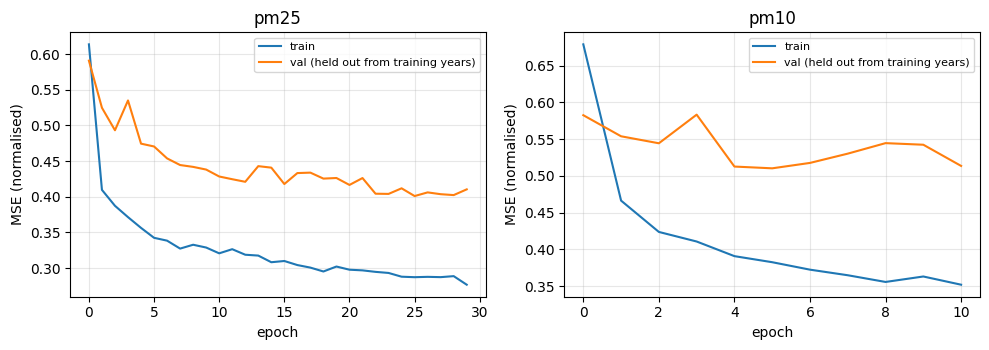


GNN covers 2 pollutant(s), 10,246 windows


In [10]:
GNN_NPZ = os.path.join(RESULTS, "gnn_predictions.npz")
GNN_CSV = os.path.join(RESULTS, "gnn_partner.csv")

if os.path.exists(GNN_NPZ):
    print("reusing cached GNN predictions")
    _z = np.load(GNN_NPZ, allow_pickle=True)
    gnn_preds = {tuple(k): v for k, v in zip(_z["keys"], _z["vals"])}
    gnn_preds = {(k[0], k[1], pd.Timestamp(k[2])): v for k, v in gnn_preds.items()}
    histories = {}
else:
    gnn_preds, histories = {}, {}
    for _p in GNN_POLLUTANTS:
        _pred, _h = train_partition(_p)
        gnn_preds.update(_pred)
        if _h:
            histories[_p] = _h
    np.savez_compressed(
        GNN_NPZ,
        keys=np.array([[k[0], k[1], str(k[2])] for k in gnn_preds], dtype=object),
        vals=np.stack(list(gnn_preds.values())) if gnn_preds else np.zeros((0, HORIZON)))

# The partner-format CSV, so the xLSTM track (or anyone else) can be dropped in
# here without touching this notebook. Long format, h = 1..24.
if gnn_preds and not os.path.exists(GNN_CSV):
    rows = [(st, p, o, h + 1, float(v[h]))
            for (st, p, o), v in gnn_preds.items() for h in range(HORIZON)]
    pd.DataFrame(rows, columns=["station", "pollutant", "origin", "h", "pred"]) \
      .to_csv(GNN_CSV, index=False)
    print("wrote", GNN_CSV)

if histories:
    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(1, len(histories), figsize=(5*len(histories), 3.6), squeeze=False)
    for ax, (p, h) in zip(axes[0], histories.items()):
        ax.plot(h["train"], label="train"); ax.plot(h["val"], label="val (held out from training years)")
        ax.set_title(p); ax.set_xlabel("epoch"); ax.set_ylabel("MSE (normalised)")
        ax.legend(fontsize=8); ax.grid(alpha=.3)
    plt.tight_layout(); plt.show()

print(f"\nGNN covers {len({p for _, p, _ in gnn_preds})} pollutant(s), "
      f"{len(gnn_preds):,} windows")

## Part 4 - the blend

```
pred = w * chronos + (1 - w) * partner
```

with `w` fitted **per (pollutant, regime)** on the 2023 set by a grid search that
minimises mean MASE, then applied unchanged to 2024. `w` is clipped to [0, 1]: a
negative weight, or one above 1, is extrapolation that a single year of tuning
data cannot support.

Deliberately **one scalar per cell** - 6 pollutants x 2 regimes at most. Fitting
anything richer (per station, per horizon hour) on a single year of tuning data
will overfit, and you will not be able to tell from the numbers that it did.

Cells with too few tuning windows fall back to `w = 1` (Chronos alone) rather
than fitting a weight on noise. That fallback is reported, not silent. Pollutants
the GNN never trained on land in exactly that case.

The 7-day diurnal climatology is scored alongside as a **reference partner** -
a real, genuinely decorrelated weak model (MASE ~1.07). It shows what a weak
partner is worth, which is the bar the GNN has to clear to have earned its
training cost.

In [11]:
def diurnal_standin(w, days=7):
    """Same-hour mean over the past week - the reference weak partner."""
    out = np.full((len(w), HORIZON), np.nan)
    for i, r in enumerate(w.itertuples()):
        y = panel[(r.station, r.pollutant)].y.to_numpy()
        j = POS[r.origin]
        c = y[j - days*24:j].reshape(days, 24)
        with np.errstate(invalid="ignore"):
            m = np.nanmean(c, axis=0)
        fb = np.nanmean(y[max(0, j - 512):j])
        out[i] = np.where(np.isnan(m), fb, m)
    return out


def partner_from_preds(preds, w):
    """Align a {(station, pollutant, origin): array} dict to `w`, row for row.
    Windows the partner never predicted come back NaN and are dropped from the
    comparison - never filled, which would let a partial partner look complete."""
    out = np.full((len(w), HORIZON), np.nan)
    for i, r in enumerate(w.itertuples()):
        v = preds.get((r.station, r.pollutant, r.origin))
        if v is not None:
            out[i] = v
    ok = np.isfinite(out).all(1)
    print(f"  matched {ok.sum():,}/{len(w):,} windows ({ok.mean():.1%})")
    return out, ok


def load_partner(path, w):
    """A partner model's CSV, long (station/pollutant/origin/h/pred) or wide
    (h01..h24)."""
    df = pd.read_csv(path, parse_dates=["origin"])
    if "h" in df.columns and "pred" in df.columns:
        df = df.pivot_table(index=["station", "pollutant", "origin"],
                            columns="h", values="pred")
        df = df.reindex(columns=range(1, HORIZON + 1))
    else:
        cols = [f"h{h:02d}" for h in range(1, HORIZON + 1)]
        miss = [c for c in cols if c not in df.columns]
        if miss:
            raise SystemExit(f"partner file is missing columns: {miss}")
        df = df.set_index(["station", "pollutant", "origin"])[cols]
    got = df.reindex(pd.MultiIndex.from_frame(w[["station", "pollutant", "origin"]]))
    ok = got.notna().all(axis=1).to_numpy()
    print(f"  matched {ok.sum():,}/{len(w):,} windows ({ok.mean():.1%})")
    return got.to_numpy(float), ok


if PARTNER_CSV:
    PARTNER_NAME = "partner_csv"
    print("partner: external CSV")
    print(" tune:"); partner_tune, ok_tune = load_partner(PARTNER_CSV, tune)
    print(" eval:"); partner_eval, ok_eval = load_partner(PARTNER_CSV, evalw)
else:
    PARTNER_NAME = "gnn"
    print("partner: the GNN from Part 3")
    print(" tune:"); partner_tune, ok_tune = partner_from_preds(gnn_preds, tune)
    print(" eval:"); partner_eval, ok_eval = partner_from_preds(gnn_preds, evalw)

standin_tune = diurnal_standin(tune)
standin_eval = diurnal_standin(evalw)

partner: the GNN from Part 3
 tune:
  matched 1,773/5,999 windows (29.6%)
 eval:
  matched 8,473/31,688 windows (26.7%)


/tmp/ipykernel_2069/373692858.py:9: RuntimeWarning: Mean of empty slice
  m = np.nanmean(c, axis=0)


In [12]:
MIN_CELL = 100          # tuning windows required before a weight is fitted
GRID = np.round(np.arange(0, 1.0001, 0.02), 3)


def mase_parts(w):
    """Per-row truth, mask and MASE denominator - constant across the weight
    grid, so they are computed once instead of 51 times."""
    Y = np.full((len(w), HORIZON), np.nan)
    M = np.zeros((len(w), HORIZON), bool)
    S = np.full(len(w), np.nan)
    for i, r in enumerate(w.itertuples()):
        y, m = bs.target(panel, r.station, r.pollutant, r.origin)
        s = bs.mase_scale(bs.context(panel, r.station, r.pollutant, r.origin, 512))
        Y[i], M[i] = y, m
        S[i] = s if (np.isfinite(s) and s > 0) else np.nan
    return Y, M, S


PARTS_TUNE = mase_parts(tune)
PARTS_EVAL = mase_parts(evalw)


def masked_mase(pred, parts, rows):
    """Mean per-window MASE over `rows`, vectorised over the whole set."""
    Y, M, S = parts
    use = rows & np.isfinite(S) & M.any(1)
    if not use.any():
        return np.nan
    err = np.where(M[use], np.abs(pred[use] - Y[use]), np.nan)
    return float(np.nanmean(np.nanmean(err, 1) / S[use]))


def fit_weights(chronos_pt, partner_pt, w, ok, parts):
    """One scalar per (pollutant, regime), fitted on 2023 only."""
    rows = []
    for (pol, reg), g in w.groupby(["pollutant", "regime"]):
        sel = np.zeros(len(w), bool)
        sel[g.index.to_numpy()] = True
        sel &= ok
        n = int(sel.sum())
        if n < MIN_CELL:
            rows.append({"pollutant": pol, "regime": reg, "n_tune": n,
                         "w_chronos": 1.0, "fitted": False,
                         "mase_chronos": np.nan, "mase_blend": np.nan})
            continue
        scores = [masked_mase(a * chronos_pt + (1 - a) * partner_pt, parts, sel)
                  for a in GRID]
        best = int(np.nanargmin(scores))
        rows.append({"pollutant": pol, "regime": reg, "n_tune": n,
                     "w_chronos": float(GRID[best]), "fitted": True,
                     "mase_chronos": scores[-1], "mase_blend": scores[best]})
    return pd.DataFrame(rows)


W = fit_weights(base_tune[:, :, MEDIAN], partner_tune, tune, ok_tune, PARTS_TUNE)
W["tune_gain_%"] = (1 - W.mase_blend / W.mase_chronos) * 100
W.to_csv(os.path.join(RESULTS, "blend_weights.csv"), index=False)

print(f"BLEND WEIGHTS - {BASE_NAME} + {PARTNER_NAME}, fitted on 2023 ONLY\n")
print(W.to_string(index=False, float_format=lambda v: f"{v:8.4f}"))
print("""
w_chronos = 1.00 means the partner earned no weight in that cell.
A LOWER w in the heating rows is the result to look for: it means the partner
contributes where Chronos is weakest.""")
if not W.fitted.all():
    print(f"\n{(~W.fitted).sum()} cell(s) had under {MIN_CELL} tuning windows "
          f"and fall back to Chronos alone.")

BLEND WEIGHTS - chronos2 + gnn, fitted on 2023 ONLY

pollutant      regime  n_tune  w_chronos  fitted  mase_chronos  mase_blend  tune_gain_%
       co     heating       0     1.0000   False           NaN         NaN          NaN
       co non_heating       0     1.0000   False           NaN         NaN          NaN
      no2     heating       0     1.0000   False           NaN         NaN          NaN
      no2 non_heating       0     1.0000   False           NaN         NaN          NaN
       o3     heating       0     1.0000   False           NaN         NaN          NaN
       o3 non_heating       0     1.0000   False           NaN         NaN          NaN
     pm10     heating     527     0.7800    True        0.7167      0.7004       2.2631
     pm10 non_heating     526     0.9200    True        0.7056      0.7022       0.4940
     pm25     heating     359     0.8800    True        1.1309      1.1185       1.0977
     pm25 non_heating     361     0.7400    True        0.6771     

## Part 5 - results

Everything below is the 2024 frozen evaluation set, scored the same way as
`baseline_windows.csv`, with blend weights that only ever saw 2023.

In [13]:
wmap = {(r.pollutant, r.regime): r.w_chronos for r in W.itertuples()}
a = evalw.set_index(["pollutant", "regime"]).index.map(wmap).to_numpy(float)[:, None]
# A window the partner never predicted keeps w = 1: Chronos alone, not a NaN.
a = np.where(ok_eval[:, None], a, 1.0)

part_safe   = np.where(np.isfinite(partner_eval), partner_eval, 0.0)
blend_q     = a[:, :, None] * base_eval + (1 - a[:, :, None]) * part_safe[:, :, None]

rows = [res_eval,
        evaluate(blend_q, evalw, "ensemble"),
        evaluate(np.repeat(standin_eval[:, :, None], len(QUANTILES), 2),
                 evalw, "diurnal7_reference")]
if ok_eval.any():
    _p = np.where(np.isfinite(partner_eval), partner_eval, np.nan)
    rows.append(evaluate(np.repeat(_p[:, :, None], len(QUANTILES), 2),
                         evalw, PARTNER_NAME))

if pq_eval_nbr is not None:
    rows.append(res_eval_nbr)

base = pd.read_csv(os.path.join(SHARED, "baseline_windows.csv"), parse_dates=["origin"])
key = ["station", "pollutant", "origin"]
base = base.merge(evalw[key].assign(_k=1), on=key, how="inner").drop(columns="_k")
base = annotate(base[base.model != "ratio_pm25"])   # pm25-only; not comparable

allm = pd.concat(rows + [base], ignore_index=True)
allm.to_csv(os.path.join(RESULTS, "ensemble_window_metrics.csv"), index=False)

print("=" * 78)
print("HEADLINE - 2024 frozen windows".center(78))
print("=" * 78, "\n")
h = (allm.groupby("model").agg(windows=("mase", "size"), mase=("mase", "mean"),
                               mae=("mae", "mean"), wql=("wql", "mean"))
         .sort_values("mase"))
h["vs_t24_%"] = (1 - h.mase / h.loc["persistence_t24", "mase"]) * 100
print(h.to_string(float_format=lambda v: f"{v:8.4f}", na_rep="   -"))

for by in ["pollutant", "regime", "season"]:
    print(f"\n\nMASE by {by}\n")
    print(allm.pivot_table(index=by, columns="model", values="mase")
             .to_string(float_format=lambda v: f"{v:7.4f}"))

# The partner is only scored where it actually predicted, so a like-for-like
# comparison needs the same subset for every model.
if ok_eval.any() and not ok_eval.all():
    sub = allm[allm.set_index(key).index.isin(
        pd.MultiIndex.from_frame(evalw.loc[ok_eval, key]))]
    print(f"\n\nON THE {int(ok_eval.sum()):,} WINDOWS THE PARTNER COVERS\n")
    print(sub.groupby("model").mase.mean().sort_values()
             .to_string(float_format=lambda v: f"{v:8.4f}"))

_c  = h.loc["chronos2", "mase"]
_b  = h.loc[BASE_NAME, "mase"]
_e  = h.loc["ensemble", "mase"]
_gain     = (1 - _e / _c) * 100          # ensemble vs plain chronos
_gain_b   = (1 - _e / _b) * 100          # ensemble vs its own base
_nbr_gain = (1 - _b / _c) * 100          # what the neighbour covariates alone gave
_verdict = ("the blend WINS - report it" if _gain >= 1 else
            "within noise - report Chronos alone as the headline")
print(f"""

{'=' * 78}
VERDICT
  spatial diagnostic (Part 1) : {SPATIAL_GAIN:+.1f}% from neighbour covariates, 400 windows
  chronos2 (weather only)     : {_c:.4f}
  {BASE_NAME:<28}: {_b:.4f}   ({_nbr_gain:+.2f}%  <- neighbours alone, no blend)
  ensemble (+ {PARTNER_NAME:<15}): {_e:.4f}   ({_gain:+.2f}% vs chronos2, {_gain_b:+.2f}% vs base)

  {_verdict}.

  Read the middle row first. If the neighbour covariates alone carry most of the
  gain, the spatial signal is real but the BLEND is not what captured it - and
  the honest headline is chronos2_nbr, not the ensemble.

  A gain under ~1% is within the noise of a single held-out year. The blend is
  only worth reporting if it beats Chronos on 2024 using weights fitted on 2023,
  which is the only comparison above that is not circular.
{'=' * 78}""")

h.to_csv(os.path.join(RESULTS, "ensemble_headline.csv"))
meta = {
    "chronos_model": MODEL, "context_hours": CONTEXT, "horizon_hours": HORIZON,
    "partner": PARTNER_NAME,
    "blend_base": BASE_NAME,
    "base_chosen_on": "2023 tuning MASE (never 2024)",
    "mase_chronos_nbr": (float(h.loc["chronos2_nbr", "mase"])
                         if "chronos2_nbr" in h.index else None),
    "gnn_pollutants": GNN_POLLUTANTS,
    "gnn_val_days_held_out_from_training": GNN_VAL_DAYS,
    "heating_months": list(HEATING_MONTHS),
    "weights_fitted_on": "2023 windows enumerated with the shared eligibility rule",
    "weights_never_fitted_on": "2024 (the evaluation year)",
    "tune_windows": int(len(tune)), "eval_windows": int(len(evalw)),
    "partner_coverage": float(ok_eval.mean()),
    "spatial_diagnostic_gain_%": float(SPATIAL_GAIN),
    "mase_chronos": float(_c), "mase_ensemble": float(_e),
    "caveat": ("weather covariates use OBSERVED future values; a deployment "
               "would substitute a numerical weather forecast"),
}
with open(os.path.join(RESULTS, "ensemble_run.json"), "w") as f:
    json.dump(meta, f, indent=2)

print("\nwritten to", os.path.abspath(RESULTS))
for f in sorted(os.listdir(RESULTS)):
    print("  ", f)

/content/shared/bih_shared.py:98: RuntimeWarning: Mean of empty slice
  mae = float(np.nanmean(np.abs(err)))
/content/shared/bih_shared.py:100: RuntimeWarning: Mean of empty slice
  "rmse": float(np.sqrt(np.nanmean(err ** 2))),


                        HEADLINE - 2024 frozen windows                        

                    windows     mase      mae      wql  vs_t24_%
model                                                           
chronos2_nbr          31688   0.7591   7.0904   0.1445   29.4912
ensemble              31688   0.7620   7.0839   0.1446   29.2154
chronos2              31688   0.7649   7.1378   0.1449   28.9479
gnn                   31688   0.9161  11.8090   0.0649   14.9042
diurnal7_reference    31688   1.0706  10.6561   0.3125    0.5525
persistence_t24       31688   1.0766  10.4397        -    0.0000
persistence_last      31688   1.2823  12.2444        -  -19.1157


MASE by pollutant

model      chronos2  chronos2_nbr  diurnal7_reference  ensemble     gnn  persistence_last  persistence_t24
pollutant                                                                                                 
co           0.7414        0.7417              1.0719    0.7414     NaN            1.3941           